# SASRec → target-conditioned QFormer → LLM recommender

Binary click/rating prediction ("Yes"/"No") on CoLLM's MovieLens-1M benchmark.
**Primary metric: UAUC** (per-user AUC averaged over users); secondary: global AUC, NDCG@k.

## Architecture

```
history ids ──> SASRec (frozen after Phase 0) ──> H ∈ [B, L, d]   (ALL positions)
                                                    │ keys/values
target id ──> e_i ──> FiLM ──> Q' = γ(e_i)·Q + β(e_i)
                                                    │ queries
                                     QFormer (self-attn + cross-attn)
                                                    │
                          N ×〈UserID〉tokens + 1 ×〈TargetItemID〉token
                                                    │  spliced into inputs_embeds
                        frozen LLM + LoRA ──> P("Yes") at the answer position
```

**Why a QFormer instead of CoLLM's MLP?** CoLLM compresses the entire history into one
pooled SASRec vector and MLP-maps it to a single soft token — an information bottleneck.
The QFormer's N learnable queries cross-attend over *every* history position, so different
queries can specialize (genre affinity, recency, niche taste) and the LLM receives N tokens
of user representation.

**Two-level target injection (by design).** The target item enters the model twice:
1. **Early** — its SASRec embedding FiLM-modulates the QFormer queries *before*
   cross-attention (`Q' = γ(e_i)·Q + β(e_i)`), so the bridge reads out *"how does this
   history relate to items like this candidate"* rather than a generic profile. γ is
   parameterized as `1 + Δγ` with `Δγ` initialized to zero, so training starts at the
   target-agnostic model and learns how much conditioning helps (`target_aware=False`
   gives the agnostic control).
2. **Late** — its title and one projected item soft token appear in the prompt, letting
   the LLM do the final semantic matching.

**Training** is phase-driven (SASRec CTR pre-training → LoRA warm-up on text-only prompts
→ QFormer-only training on the hybrid prompt), the loss adds a **within-user pairwise
(BPR) term** that directly targets UAUC, and the final model is a **weight-averaged soup**
of the top-k checkpoints selected by *smoothed* validation UAUC with a bootstrap noise band.


## ⬇ Google Colab setup (skip if running locally)

Open this notebook straight from GitHub (`File → Open notebook → GitHub`) and run the
cell below: it clones the repo, installs the two packages Colab lacks, and unpacks the
CoLLM ML-1M data. On a **T4 (16 GB)** use `cfg.load_4bit = True` for the full Vicuna-7B
run; an A100 runs it in bf16 without quantization.

In [1]:
!pip -q uninstall -y torchao


In [12]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("config.py"):
    !git clone https://github.com/htainvn/qformer-rec.git repo_src
    %cd repo_src
    %pip -q install peft accelerate bitsandbytes
    !unzip -o -q ml-1m.zip
    print("Colab setup done:", os.getcwd())

## 0 · Configuration

`smoke_test=True` (default) runs the whole pipeline on tiny synthetic data with a tiny
random GPT-2 backbone — CPU-only, a few minutes end-to-end. The clearly marked cell below
switches to the full Vicuna-7B multi-seed run on the real ML-1M pickles (needs a GPU).

In [3]:
import numpy as np, torch, matplotlib.pyplot as plt, json, warnings
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader

from config import Config
from data import load_data, collate
from models import SASRec
from models.llm_rec import fill_titles
from train import (seed_everything, train_phase0, train_phase1, train_phase2,
                   build_models, load_tracked_state, eval_sasrec, run_all_phases)
from evaluate import (score_dataset, full_report, paired_user_test, qualifying_users,
                      comparison_table, ndcg_at_k, stratified_uauc, support_weighted_uauc,
                      BASELINES, TARGETS, auc as auc_fn, uauc as uauc_fn)

cfg = Config.smoke()          # <- default: runs out of the box on CPU
SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
print(f"backbone={cfg.backbone}  smoke_test={cfg.smoke_test}  seeds={SEEDS}")

backbone=hf-internal-testing/tiny-random-gpt2  smoke_test=True  seeds=[42, 43]


### ⚠️ FULL RUN — uncomment to train Vicuna-7B on the real ML-1M (GPU required)
This is the configuration used for the reported numbers: `lmsys/vicuna-7b-v1.5` frozen +
LoRA(r=8, α=16 on q_proj/v_proj), 3 seeds, model soup of top-3 checkpoints. Expect several
hours per seed on a single A100 (use `load_4bit=True` to fit smaller GPUs).

In [4]:
cfg = Config()                       # full ML-1M + Vicuna-7B
cfg.n_seeds = 3                        # 3-5 seeds for the reported mean ± std
# cfg.load_4bit = True                 # QLoRA-quantize the frozen backbone if VRAM-bound
# cfg.unfreeze_sasrec = True           # Phase 2b variant
# cfg.qformer_align_pretrain = True    # optional contrastive QFormer init
SEEDS = list(range(cfg.seed, cfg.seed + cfg.n_seeds))
print(f"backbone={cfg.backbone}  seeds={SEEDS}")

backbone=lmsys/vicuna-7b-v1.5  seeds=[42, 43, 44]


## 1 · Data

CoLLM's preprocessed ML-1M (timestamp-split, label = rating > 3): 839 users, 3,256 items,
33,891 / 10,401 / 7,331 train/val/test. Ids are 1-based with 0 as the padding/no-history
placeholder; histories are capped to the 10 most recent liked items and left-padded.
In smoke mode a latent-factor synthetic dataset with the same schema is generated instead.

In [5]:
seed_everything(cfg.seed)
DEVICE = cfg.resolve_device()
train_ds, val_ds, test_ds, n_users, n_items, id2title = load_data(cfg)

print(f"device={DEVICE}")
print(f"train/val/test = {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
print(f"n_users={n_users}  n_items={n_items}  titles={len(id2title)}")
labels = train_ds.label
print(f"train positive rate: {labels.mean():.3f}")
his_lens = [int(m) for m in (np.array([sum(1 for i in h if i != 0) for h in train_ds.his]))]
print(f"history length (post-cap): mean {np.mean(his_lens):.1f}, max {max(his_lens)}")

device=cuda
train/val/test = 33891 / 10401 / 7331
n_users=839  n_items=3255  titles=3255
train positive rate: 0.537
history length (post-cap): mean 8.3, max 10


In [6]:
# A sample prompt, exactly as the LLM sees it (soft-token slots marked):
s = train_ds[min(500, len(train_ds) - 1)]
seg_a, seg_b, seg_c = fill_titles(s["his_titles"], s["target_title"], hybrid=True)
print(seg_a + f"[{cfg.n_queries} × <UserID soft tokens>]" + seg_b
      + "[1 × <TargetItemID soft token>]" + seg_c)
print("\nlabel:", s["label"])

#Question: A user has given high ratings to the following movies: "Raiders of the Lost Ark (1981)", "Star Wars: Episode IV - A New Hope (1977)", "Dead Poets Society (1989)". Additionally, we have information about the user's preferences encoded in the feature [4 × <UserID soft tokens>]. Using all available information, make a prediction about whether the user would enjoy the movie titled "Seven (Se7en) (1995)" with the feature [1 × <TargetItemID soft token>]? Answer with "Yes" or "No". 
#Answer:

label: 1.0


## 2 · Phase 0 — SASRec pre-training (sequential CTR, BCE)

SASRec trains standalone: dot(last hidden state, target item embedding) → BCE. The best
epoch by val AUC is saved to `checkpoints/sasrec.pt` and frozen for Phases 1–2 (unless
`unfreeze_sasrec` re-opens it in Phase 2b).

[phase0] epoch 1/30 loss 0.6537 val AUC 0.6851 val UAUC 0.6737
[phase0] epoch 2/30 loss 0.5949 val AUC 0.6852 val UAUC 0.6665
[phase0] epoch 3/30 loss 0.5697 val AUC 0.6854 val UAUC 0.6673
[phase0] epoch 4/30 loss 0.5344 val AUC 0.6848 val UAUC 0.6675
[phase0] epoch 5/30 loss 0.4898 val AUC 0.6803 val UAUC 0.6582
[phase0] epoch 6/30 loss 0.4425 val AUC 0.6710 val UAUC 0.6455
[phase0] epoch 7/30 loss 0.3992 val AUC 0.6542 val UAUC 0.6272
[phase0] epoch 8/30 loss 0.3634 val AUC 0.6477 val UAUC 0.6287
[phase0] epoch 9/30 loss 0.3305 val AUC 0.6526 val UAUC 0.6406
[phase0] epoch 10/30 loss 0.3000 val AUC 0.6476 val UAUC 0.6230
[phase0] epoch 11/30 loss 0.2725 val AUC 0.6443 val UAUC 0.6270
[phase0] epoch 12/30 loss 0.2528 val AUC 0.6449 val UAUC 0.6311
[phase0] epoch 13/30 loss 0.2315 val AUC 0.6361 val UAUC 0.6164
[phase0] epoch 14/30 loss 0.2149 val AUC 0.6395 val UAUC 0.6225
[phase0] epoch 15/30 loss 0.2009 val AUC 0.6372 val UAUC 0.6129
[phase0] epoch 16/30 loss 0.1870 val AUC 0.6364 v

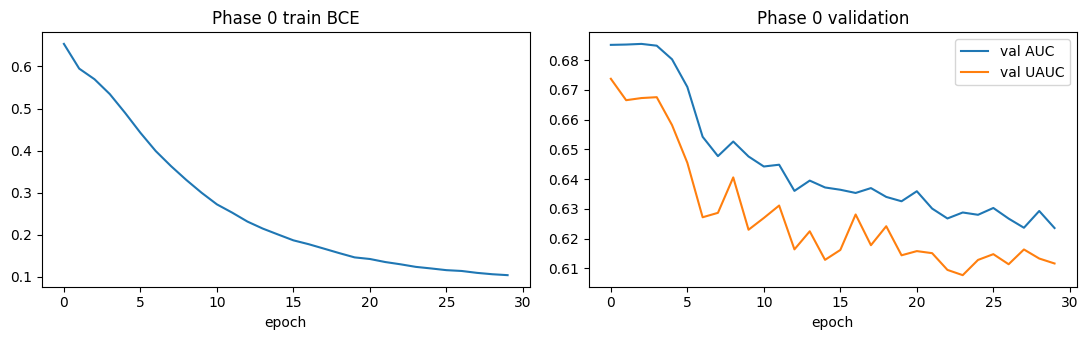

In [7]:
sasrec, hist0 = train_phase0(cfg, train_ds, val_ds, n_items, DEVICE)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist0["loss"]); ax[0].set_title("Phase 0 train BCE"); ax[0].set_xlabel("epoch")
ax[1].plot(hist0["val_auc"], label="val AUC"); ax[1].plot(hist0["val_uauc"], label="val UAUC")
ax[1].set_title("Phase 0 validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3 · Phase 1 — LoRA warm-up on the text-only prompt

The LLM (backbone frozen; only LoRA trains) first learns the *task format* — answer
"Yes"/"No" about a movie given history titles — with **no** collaborative tokens. This way
Phase 2's gradients reflect collaborative signal rather than prompt-format learning.
The loss is already BCE + λ·within-user BPR (the pairwise term needs the user-grouped
batch sampler, which guarantees same-user positive/negative pairs inside a batch).

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

model.safetensors.index.json:   0%|          | 0.00/28.1k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[phase1] 4,194,304 trainable params, 282 qualifying val users for selection
[select] step 200: val UAUC 0.6733 (smoothed 0.6733) val AUC 0.6863
[select] step 400: val UAUC 0.6869 (smoothed 0.6801) val AUC 0.6947
[select] step 600: val UAUC 0.6836 (smoothed 0.6813) val AUC 0.6989
[select] step 800: val UAUC 0.6818 (smoothed 0.6841) val AUC 0.7008
[select] step 1000: val UAUC 0.6829 (smoothed 0.6828) val AUC 0.7043
[select] step 1200: val UAUC 0.6816 (smoothed 0.6821) val AUC 0.7056
[select] step 1400: val UAUC 0.6788 (smoothed 0.6811) val AUC 0.7038
[select] step 1600: val UAUC 0.6775 (smoothed 0.6793) val AUC 0.7078
[select] step 1800: val UAUC 0.6781 (smoothed 0.6781) val AUC 0.7069
[select] step 2000: val UAUC 0.6829 (smoothed 0.6795) val AUC 0.7093
[phase1] early stop at step 2000 (patience)
[phase1] epoch 1/1 mean loss 0.8804
[select] noise band ±0.0254: 10 checkpoint(s) tied at top
[phase1] saved LoRA -> checkpoints/lora_phase1.pt


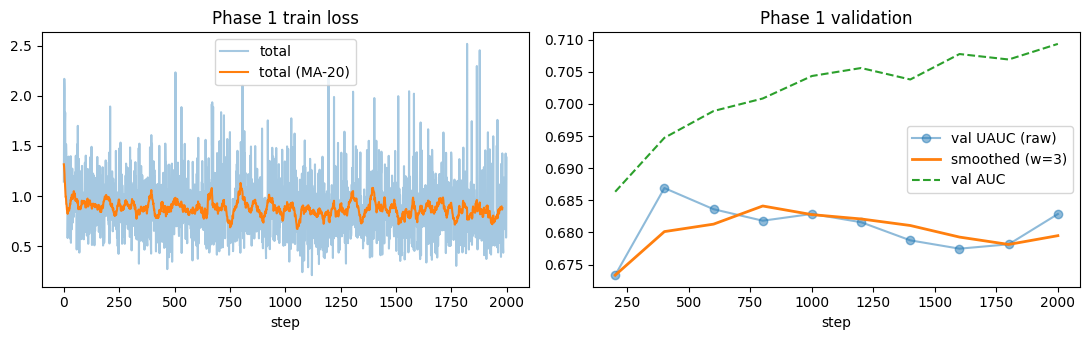

In [8]:
llm, _, qformer = build_models(cfg, n_items, DEVICE)
sasrec = sasrec.to(DEVICE)

sel1, hist1 = train_phase1(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps1, raw1, smooth1, auc1 = sel1.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist1["loss"], alpha=.4, label="total")
ax[0].plot(np.convolve(hist1["loss"], np.ones(20)/20, mode="valid"), label="total (MA-20)")
ax[0].set_title("Phase 1 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps1, raw1, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps1, smooth1, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps1, auc1, "--", label="val AUC")
ax[1].set_title("Phase 1 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Phase 2 — train the QFormer bridge on the full hybrid prompt

LLM **and** LoRA are now frozen (Phase-1 weights loaded); only the QFormer + projection
heads receive gradients — which flow through `inputs_embeds` at the soft-token positions.
SASRec stays frozen (Phase 2b flips `cfg.unfreeze_sasrec`). We deliberately do **not**
train LoRA and the QFormer jointly in one step: per CoLLM's ablations the LoRA gradient
dominates early and the mapping module never learns to carry collaborative information
(worst on cold users).

Checkpoint selection here is the robust machinery from `selection.py`: smoothed val UAUC
+ bootstrap noise band (AUC breaks ties only inside the band) + patience early stopping;
the final model is the **weight-averaged soup** of the top-k checkpoints.

[phase2] 34,241,472 trainable params, 282 qualifying val users for selection
[select] step 200: val UAUC 0.6844 (smoothed 0.6844) val AUC 0.6896
[select] step 400: val UAUC 0.6783 (smoothed 0.6814) val AUC 0.6890
[select] step 600: val UAUC 0.6807 (smoothed 0.6812) val AUC 0.6894
[select] step 800: val UAUC 0.6808 (smoothed 0.6799) val AUC 0.6916
[select] step 1000: val UAUC 0.6809 (smoothed 0.6808) val AUC 0.6915
[select] step 1200: val UAUC 0.6749 (smoothed 0.6789) val AUC 0.6906
[select] step 1400: val UAUC 0.6866 (smoothed 0.6808) val AUC 0.6902
[phase2] early stop at step 1400 (patience)
[phase2] epoch 1/3 mean loss 0.7511
[select] noise band ±0.0261: 7 checkpoint(s) tied at top
[select] souping 3 checkpoints from steps [800, 1000, 1200]
[phase2] saved souped QFormer -> checkpoints/qformer.pt


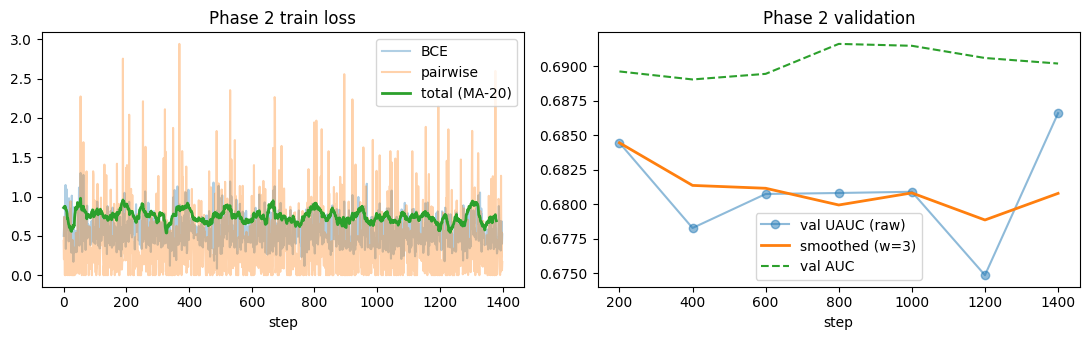

In [13]:
if cfg.qformer_align_pretrain:
    from train import align_pretrain_qformer
    align_pretrain_qformer(cfg, sasrec, qformer, train_ds, DEVICE)

sel2, hist2 = train_phase2(cfg, llm, sasrec, qformer, train_ds, val_ds, DEVICE)

steps2, raw2, smooth2, auc2 = sel2.curves()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist2["bce"], alpha=.35, label="BCE")
ax[0].plot(hist2["pair"], alpha=.35, label="pairwise")
ax[0].plot(np.convolve(hist2["loss"], np.ones(20)/20, mode="valid"), lw=2, label="total (MA-20)")
ax[0].set_title("Phase 2 train loss"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(steps2, raw2, "o-", alpha=.5, label="val UAUC (raw)")
ax[1].plot(steps2, smooth2, "-", lw=2, label=f"smoothed (w={cfg.sel_window})")
ax[1].plot(steps2, auc2, "--", label="val AUC")
ax[1].set_title("Phase 2 validation"); ax[1].set_xlabel("step"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5 · Model soup + test evaluation (seed 0)

`train_phase2` already loaded the top-k soup into the QFormer. We score the test split
once with the souped model, and also score the Phase-0 SASRec alone — the collaborative
baseline for the paired per-user comparison.

In [14]:
uids_t, labels_t, scores_t = score_dataset(
    llm, sasrec, qformer, test_ds, batch_size=cfg.phase2_batch_size * 2, device=DEVICE)

# fixed qualifying-user set: computed once, reused for every model/seed below
TEST_USERS = qualifying_users(uids_t, labels_t)
print(f"qualifying test users (both classes present): {len(TEST_USERS)}"
      f" of {len(np.unique(uids_t))}")

# SASRec-only baseline scores on the identical samples
with torch.no_grad():
    dl = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=collate)
    sasrec_scores = np.concatenate([
        torch.sigmoid(sasrec.ctr_logit(b.his.to(DEVICE), b.his_mask.to(DEVICE),
                                       b.iid.to(DEVICE))).cpu().numpy() for b in dl])

seed_scores = {SEEDS[0]: scores_t}
rep0 = full_report(uids_t, labels_t, scores_t, TEST_USERS, n_boot=cfg.n_boot,
                   ndcg_ks=cfg.ndcg_ks, seed=cfg.seed)
print(json.dumps({k: v for k, v in rep0.items() if k != "stratified_uauc"},
                 indent=2, default=str))

qualifying test users (both classes present): 224 of 320
{
  "auc": 0.7044003925154897,
  "uauc": 0.6860841564008525,
  "uauc_ci": [
    0.6534698932320221,
    0.7158146521455102
  ],
  "n_qualifying_users": 224,
  "support_weighted_uauc": 0.693041722284539,
  "ndcg": {
    "5": 0.8284139904479176,
    "10": 0.8437339042109496
  }
}


## 6 · Multi-seed runs

The targets sit above published SOTA, so no single lucky run counts: every reported number
is a mean over seeds, and every UAUC carries a bootstrap CI over users. Each extra seed
re-runs all three phases end-to-end.

In [15]:
for seed in SEEDS[1:]:
    print(f"\n=== seed {seed} " + "=" * 50)
    run = run_all_phases(cfg, seed=seed)
    llm_s, sasrec_s, qformer_s = run["models"]
    _, _, s = score_dataset(llm_s, sasrec_s, qformer_s, test_ds,
                            batch_size=cfg.phase2_batch_size * 2, device=run["device"])
    seed_scores[seed] = s
    del run, llm_s, sasrec_s, qformer_s
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\ncollected test scores for seeds: {sorted(seed_scores)}")


=== seed 43 ==================================================
[run] seed 43, device cuda, smoke_test=False
[phase0] epoch 1/30 loss 0.6552 val AUC 0.6851 val UAUC 0.6815
[phase0] epoch 2/30 loss 0.5950 val AUC 0.6871 val UAUC 0.6834
[phase0] epoch 3/30 loss 0.5721 val AUC 0.6864 val UAUC 0.6764
[phase0] epoch 4/30 loss 0.5383 val AUC 0.6808 val UAUC 0.6685
[phase0] epoch 5/30 loss 0.4922 val AUC 0.6693 val UAUC 0.6598
[phase0] epoch 6/30 loss 0.4450 val AUC 0.6662 val UAUC 0.6679
[phase0] epoch 7/30 loss 0.3980 val AUC 0.6606 val UAUC 0.6528
[phase0] epoch 8/30 loss 0.3589 val AUC 0.6486 val UAUC 0.6450
[phase0] epoch 9/30 loss 0.3226 val AUC 0.6505 val UAUC 0.6525
[phase0] epoch 10/30 loss 0.2946 val AUC 0.6428 val UAUC 0.6415
[phase0] epoch 11/30 loss 0.2675 val AUC 0.6479 val UAUC 0.6458
[phase0] epoch 12/30 loss 0.2471 val AUC 0.6416 val UAUC 0.6400
[phase0] epoch 13/30 loss 0.2281 val AUC 0.6415 val UAUC 0.6383
[phase0] epoch 14/30 loss 0.2086 val AUC 0.6379 val UAUC 0.6378
[pha

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[phase1] 4,194,304 trainable params, 282 qualifying val users for selection


OutOfMemoryError: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 33.44 MiB is free. Including non-PyTorch memory, this process has 39.45 GiB memory in use. Of the allocated memory 36.70 GiB is allocated by PyTorch, and 2.24 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 7 · Results

* **Headline**: test AUC / UAUC as mean ± std over seeds; UAUC with a bootstrap CI over
  users (computed on per-user AUCs averaged across seeds — the seed-level uncertainty and
  user-level uncertainty are reported separately, not conflated).
* **Paired comparison** vs the SASRec baseline: mean per-user AUC difference with a
  bootstrap test over users — the correct way to claim a win, since pairing removes
  between-user variance.
* **Diagnostics** (alongside, never as headline): support-weighted UAUC, UAUC stratified
  by user support (all qualifying users are always reported too — nobody gets silently
  dropped), NDCG@{5,10}.

In [ ]:
from evaluate import per_user_auc

per_seed_auc  = {s: auc_fn(labels_t, sc) for s, sc in seed_scores.items()}
per_seed_uauc = {s: uauc_fn(uids_t, labels_t, sc, TEST_USERS) for s, sc in seed_scores.items()}
auc_mean, auc_std   = np.mean(list(per_seed_auc.values())),  np.std(list(per_seed_auc.values()))
uauc_mean, uauc_std = np.mean(list(per_seed_uauc.values())), np.std(list(per_seed_uauc.values()))
print("per-seed AUC :", {s: round(v, 4) for s, v in per_seed_auc.items()})
print("per-seed UAUC:", {s: round(v, 4) for s, v in per_seed_uauc.items()})

# bootstrap CI over USERS on the seed-averaged per-user AUCs
pu_by_seed = [per_user_auc(uids_t, labels_t, sc, TEST_USERS) for sc in seed_scores.values()]
user_mat = np.array([[pu[int(u)][0] for pu in pu_by_seed] for u in TEST_USERS]).mean(axis=1)
rng = np.random.default_rng(cfg.seed)
boot = rng.choice(user_mat, size=(cfg.n_boot, len(user_mat)), replace=True).mean(axis=1)
uauc_ci = (float(np.quantile(boot, .025)), float(np.quantile(boot, .975)))
print(f"\nUAUC {uauc_mean:.4f} ± {uauc_std:.4f} (seed std) | 95% user-bootstrap CI"
      f" [{uauc_ci[0]:.4f}, {uauc_ci[1]:.4f}]")

per-seed AUC : {42: 0.4746, 43: 0.4745}
per-seed UAUC: {42: 0.4739, 43: 0.4744}

UAUC 0.4741 ± 0.0002 (seed std) | 95% user-bootstrap CI [0.3894, 0.5472]


In [ ]:
# Paired per-user comparison vs the SASRec baseline (seed-0 scores)
paired = paired_user_test(uids_t, labels_t, seed_scores[SEEDS[0]], sasrec_scores,
                          TEST_USERS, n_boot=cfg.n_boot, seed=cfg.seed)
print("paired vs SASRec-only:", json.dumps(paired, indent=2))
verdict = ("BEATS baseline (CI excludes 0)" if paired["ci"][0] > 0 else
           "does NOT significantly beat baseline" if paired["ci"][1] > 0 else
           "significantly WORSE than baseline")
print("→", verdict)

paired vs SASRec-only: {
  "mean_diff": -0.06759798157946306,
  "ci": [
    -0.16507348006074857,
    0.042690543552812064
  ],
  "p_boot": 0.25,
  "n_users": 54
}
→ does NOT significantly beat baseline


In [ ]:
print(comparison_table(auc_mean, auc_std, uauc_mean, uauc_std, uauc_ci, len(SEEDS)))

mean_scores = np.mean([seed_scores[s] for s in SEEDS], axis=0)
print("\n--- diagnostics (seed-averaged scores; alongside, not headline) ---")
print(f"support-weighted UAUC: {support_weighted_uauc(uids_t, labels_t, mean_scores, TEST_USERS):.4f}")
for k, (v, n) in stratified_uauc(uids_t, labels_t, mean_scores, TEST_USERS).items():
    print(f"UAUC (support {k}): {v:.4f}  ({n} users; standard all-user UAUC above)")
for k, v in ndcg_at_k(uids_t, labels_t, mean_scores, ks=cfg.ndcg_ks).items():
    print(f"NDCG@{k}: {v:.4f}")

Model                     | UAUC                               | AUC             | Notes          
--------------------------+------------------------------------+-----------------+----------------
Ours (SASRec+QFormer+LLM) | 0.4741 ± 0.0002 (CI 0.3894–0.5472) | 0.4745 ± 0.0001 | mean of 2 seeds
CoLLM-SASRec              | 0.6990                             | 0.7235          | published      
BinLLM                    | 0.6956                             | 0.7425          | published      
CoLLM-MF                  | 0.6875                             | —               | published      
TARGET                    | 0.71                               | 0.75            |                

--- diagnostics (seed-averaged scores; alongside, not headline) ---
support-weighted UAUC: 0.4643
UAUC (support >=5): 0.4411  (43 users; standard all-user UAUC above)
UAUC (support >=10): 0.4299  (11 users; standard all-user UAUC above)


NDCG@5: 0.6525
NDCG@10: 0.7611


## 8 · Conclusion

* The pipeline — SASRec → FiLM-target-conditioned QFormer → frozen LLM + LoRA — runs
  end-to-end: phase-wise training, within-user pairwise loss, smoothed-UAUC checkpoint
  selection with a bootstrap noise band, and a top-k weight-averaged soup.
* In `smoke_test` mode (this default run) the numbers are chance-level by construction:
  a randomly initialized 32-dim GPT-2 on synthetic data exists only to prove the plumbing.
  Real conclusions require the marked full-run cell: Vicuna-7B on CoLLM's ML-1M,
  ≥3 seeds.
* Claiming a win means: multi-seed mean UAUC with its user-bootstrap CI above
  CoLLM-SASRec's 0.6990, **and** a paired per-user bootstrap CI excluding zero — not one
  lucky checkpoint.
* If the full run plateaus below the 0.71 UAUC target, the documented escalation path is
  **Design 2 (DIN-fused values)** in `models/README.md`: concatenate DIN's pre-pool
  target-weighted per-position states with SASRec's states as QFormer keys/values —
  strictly more expressive target injection, at the cost of a second encoder.